<a href="https://colab.research.google.com/github/Swathi014/DEEP-LEARNING/blob/main/Heart_Disease_Prediction_using_Deep_Neural_Network_(Keras_TensorFlow).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Heart Disease Prediction using Deep Neural Network (Keras/TensorFlow)

In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import tensorflow as tf
from tensorflow import keras

In [ ]:
keras.utils.set_random_seed(42)

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/DL LAB S2/3/heart.csv")

In [ ]:
print(df.shape)

(303, 14)


In [ ]:
print(df["target"].value_counts(normalize=True, dropna=False))

target
0    0.726073
1    0.273927
Name: proportion, dtype: float64


In [ ]:
categorical_variables = ['sex','cp','fbs','restecg','exang','ca','thal']
numerical_variables = ['age','trestbps','chol','thalach','oldpeak','slope']

In [ ]:
# one-hot encoding
df = pd.get_dummies(df, columns=categorical_variables)

In [ ]:
test_df = df.sample(frac=0.2, random_state=42)
train_df = df.drop(test_df.index)

In [ ]:
mean = train_df[numerical_variables].mean()
std = train_df[numerical_variables].std()

In [ ]:
train_df[numerical_variables] = (train_df[numerical_variables] - mean) / std
test_df[numerical_variables]  = (test_df[numerical_variables] - mean) / std

In [ ]:
print(train_df.head())

        age  trestbps      chol   thalach   oldpeak     slope  target  sex_0  \
0  0.963746  0.721939 -0.278690  0.008396  1.083461  2.226814       0  False   
1  1.405254  1.554681  0.814423 -1.807247  0.399542  0.646494       1  False   
2  1.405254 -0.665964 -0.361189 -0.899426  1.339930  0.646494       0  False   
3 -1.906055 -0.110803  0.071931  1.607891  2.109339  2.226814       0  False   
4 -1.464547 -0.110803 -0.876809  0.959447  0.314052 -0.933825       0   True   

   sex_1   cp_0  ...  exang_1   ca_0   ca_1   ca_2   ca_3  thal_1  thal_2  \
0   True  False  ...    False   True  False  False  False   False   False   
1   True  False  ...     True  False  False  False   True   False   False   
2   True  False  ...     True  False  False   True  False   False   False   
3   True  False  ...    False   True  False  False  False   False   False   
4  False  False  ...    False   True  False  False  False   False   False   

   thal_fixed  thal_normal  thal_reversible  
0        T

In [ ]:
train_y = train_df["target"].values
test_y  = test_df["target"].values

In [ ]:
train_X = train_df.drop(columns=["target"])
test_X  = test_df.drop(columns=["target"])

In [ ]:
train_X = train_X.astype(np.float32).values
test_X  = test_X.astype(np.float32).values
train_y = train_y.astype(np.float32)
test_y  = test_y.astype(np.float32)

In [ ]:
num_columns = train_X.shape[1]

In [ ]:
inputs = keras.Input(shape=(num_columns,))

In [ ]:
h1 = keras.layers.Dense(16, activation="relu", name="Hidden_1")(inputs)
h2 = keras.layers.Dense(16, activation="relu", name="Hidden_2")(h1)
h3 = keras.layers.Dense(16, activation="relu", name="Hidden_3")(h2)

In [ ]:
outputs = keras.layers.Dense(1, activation="sigmoid", name="Output")(h3)

In [ ]:
model = keras.Model(inputs, outputs)

In [ ]:
print(model.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 29)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_1 (Dense)                │ (None, 16)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_2 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_3 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,041 (4.07 KB)

 Trainable params: 1,041 (4.07 KB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
try:
    keras.utils.plot_model(model, show_shapes=True)
except:
    print("Graphviz not installed, skipping model plot")

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    train_X,
    train_y,
    epochs=300,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


history_dict = history.history

loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
epochs = range(1, len(loss_values) + 1)

Epoch 1/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.6425 - loss: 0.6713 - val_accuracy: 0.6327 - val_loss: 0.6699
Epoch 2/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7202 - loss: 0.6527 - val_accuracy: 0.6531 - val_loss: 0.6603
Epoch 3/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7565 - loss: 0.6382 - val_accuracy: 0.7143 - val_loss: 0.6502
Epoch 4/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7979 - loss: 0.6234 - val_accuracy: 0.7143 - val_loss: 0.6386
Epoch 5/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7824 - loss: 0.6080 - val_accuracy: 0.7143 - val_loss: 0.6266
Epoch 6/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7927 - loss: 0.5917 - val_accuracy: 0.7143 - val_loss: 0.6139
Epoch 7/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8135 - loss: 0.5737 - val_accuracy: 0.7143 - val_loss: 0.6007
Epoch 8/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8290 - loss: 0.5540 - val_accuracy: 0.7143 - val_loss:

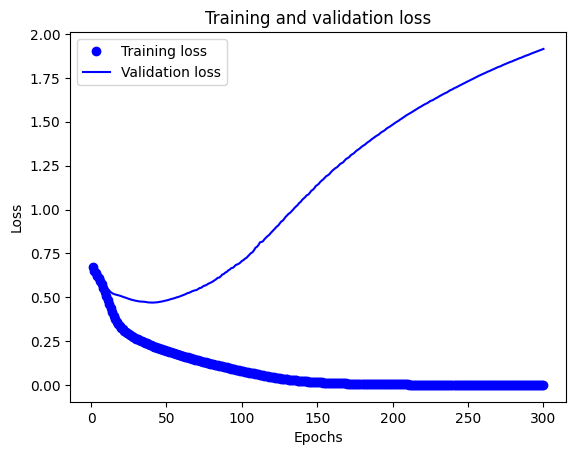

In [ ]:
plt.plot(epochs, loss_values, "bo", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

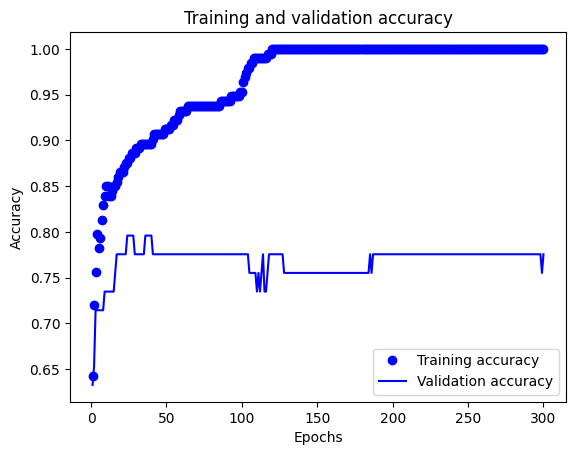

In [ ]:
plt.clf()
acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]

plt.plot(epochs, acc, "bo", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(test_X, test_y, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 1.2115
Test Accuracy: 0.8361
